Train shape: (33588, 785)
Test shape: (9911, 785)
Training Image Shape: (33587, 28, 28, 1)
Testing Image Shape: (10, 28, 28, 1)


/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/5
525/525 ━━━━━━━━━━━━━━━━━━━━ 19s 35ms/step - accuracy: 0.7952 - loss: 0.5657 - val_accuracy: 0.2000 - val_loss: 7.4671
Epoch 2/5
525/525 ━━━━━━━━━━━━━━━━━━━━ 19s 36ms/step - accuracy: 0.8679 - loss: 0.3717 - val_accuracy: 0.1000 - val_loss: 8.7805
Epoch 3/5
525/525 ━━━━━━━━━━━━━━━━━━━━ 18s 34ms/step - accuracy: 0.8832 - loss: 0.3224 - val_accuracy: 0.1000 - val_loss: 8.5838
Epoch 4/5
525/525 ━━━━━━━━━━━━━━━━━━━━ 19s 36ms/step - accuracy: 0.8955 - loss: 0.2880 - val_accuracy: 0.1000 - val_loss: 8.8610
Epoch 5/5
525/525 ━━━━━━━━━━━━━━━━━━━━ 18s 35ms/step - accuracy: 0.9030 - loss: 0.2624 - val_accuracy: 0.1000 - val_loss: 8.7579
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 37ms/step - accuracy: 0.1000 - loss: 8.7579
Test Accuracy: 0.10000000149011612
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 77ms/step
Actual    : [0 1 2 3 4 5 6 7 8 9]
Predicted : [8 8 0 0 0 4 5 4 8 1]


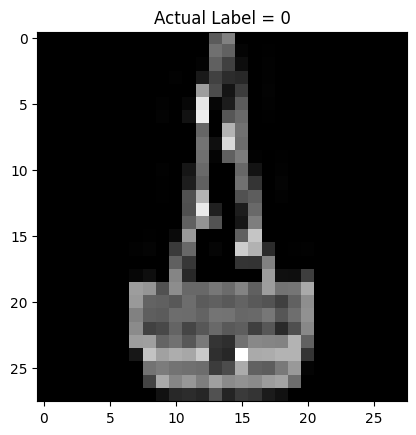

In [6]:
import pandas as pd
import numpy as np
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense
import matplotlib.pyplot as plt

# Load train dataset
train_df = pd.read_csv("fashion-mnist_train.csv")

# Load test dataset
test_df = pd.read_csv("fashion-mnist_test.csv")

print("Train shape:", train_df.shape)
print("Test shape:", test_df.shape)

# Rename 'Id' column to 'label' in test_df if it exists, to match train_df
if 'Id' in test_df.columns and 'label' not in test_df.columns:
    test_df = test_df.rename(columns={'Id': 'label'})

# Clean dataframes by dropping rows with NaN values
train_df = train_df.dropna()
test_df = test_df.dropna()

# Ensure labels are integers
train_df['label'] = train_df['label'].astype(int)
test_df['label'] = test_df['label'].astype(int)

# Filter labels to be within the valid range [0, 9]
train_df = train_df[train_df['label'].between(0, 9)]
test_df = test_df[test_df['label'].between(0, 9)]

# Separate X and y
X_train = train_df.drop("label", axis=1).values
y_train = train_df["label"].values

X_test = test_df.drop("label", axis=1).values
y_test = test_df["label"].values

# Normalize
X_train = X_train / 255.0
X_test = X_test / 255.0

# Reshape into image format
X_train = X_train.reshape(-1, 28, 28, 1)
X_test = X_test.reshape(-1, 28, 28, 1)

print("Training Image Shape:", X_train.shape)
print("Testing Image Shape:", X_test.shape)

# Build CNN model
model = Sequential([
    Conv2D(32, (3,3), activation='relu', input_shape=(28,28,1)),
    MaxPooling2D((2,2)),

    Conv2D(64, (3,3), activation='relu'),
    MaxPooling2D((2,2)),

    Flatten(),

    Dense(128, activation='relu'),
    Dense(10, activation='softmax')
])

# Compile
model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

# Train
model.fit(
    X_train,
    y_train,
    epochs=5,
    batch_size=64,
    validation_data=(X_test, y_test)
)

# Evaluate
loss, accuracy = model.evaluate(X_test, y_test)
print("Test Accuracy:", accuracy)

# Predict
pred = model.predict(X_test)
predicted_class = np.argmax(pred, axis=1)

print("Actual    :", y_test[:10])
print("Predicted :", predicted_class[:10])

# Show sample
plt.imshow(X_test[0].reshape(28,28), cmap='gray')
plt.title("Actual Label = " + str(y_test[0]))
plt.show()